In [1]:
pip install lime shap matplotlib scikit-image


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image
import matplotlib.pyplot as plt


In [3]:
def predict_fn(images):
    # images: [N, H, W, 3] in [0, 255]
    images = torch.tensor(images.transpose((0, 3, 1, 2)), dtype=torch.float32) / 255.0
    images = images.to(device)
    with torch.no_grad():
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()


In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Assume 'model' is your pretrained ViT loaded and set to eval mode
# and 'device' is either 'cuda' or 'cpu'

def predict_fn(images):
    """
    LIME requires a prediction function that takes a list of images
    in [H, W, 3] format and returns a numpy array of shape [N, num_classes]
    """
    images = torch.tensor(images.transpose((0, 3, 1, 2)), dtype=torch.float32) / 255.0
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)

    return probs.cpu().numpy()


In [ ]:
import os
from PIL import Image

# -----------------------------
# Paths
# -----------------------------
input_dir = "F://data_set//"       # e.g., dataset/train/AD (or base path for multiple classes)
output_dir = "F://rgb_converted_dataset"  # where RGB images will be saved

# -----------------------------
# Convert Function
# -----------------------------
def convert_grayscale_to_rgb(input_dir, output_dir):
    for root, _, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                input_path = os.path.join(root, file)

                # Build corresponding output path
                relative_path = os.path.relpath(root, input_dir)
                output_subdir = os.path.join(output_dir, relative_path)
                os.makedirs(output_subdir, exist_ok=True)

                output_path = os.path.join(output_subdir, file)

                # Open and convert image
                img = Image.open(input_path).convert("RGB")
                img.save(output_path)

                print(f"Converted: {input_path} -> {output_path}")

# -----------------------------
# Run Conversion
# -----------------------------
convert_grayscale_to_rgb(input_dir, output_dir)


Converted: F://data_set//rgb\dim0_slice100I101541_brainMaskedByDL.jpg -> f://rgb_converted_dataset\rgb\dim0_slice100I101541_brainMaskedByDL.jpg
Converted: F://data_set//rgb\dim0_slice100I103276_brainMaskedByDL.jpg -> f://rgb_converted_dataset\rgb\dim0_slice100I103276_brainMaskedByDL.jpg
Converted: F://data_set//rgb\dim0_slice100I106467_brainMaskedByDL.jpg -> f://rgb_converted_dataset\rgb\dim0_slice100I106467_brainMaskedByDL.jpg
Converted: F://data_set//rgb\dim0_slice100I118880_brainMaskedByDL.jpg -> f://rgb_converted_dataset\rgb\dim0_slice100I118880_brainMaskedByDL.jpg
Converted: F://data_set//rgb\dim0_slice100I119729_brainMaskedByDL.jpg -> f://rgb_converted_dataset\rgb\dim0_slice100I119729_brainMaskedByDL.jpg
Converted: F://data_set//rgb\dim0_slice100I119731_brainMaskedByDL.jpg -> f://rgb_converted_dataset\rgb\dim0_slice100I119731_brainMaskedByDL.jpg
Converted: F://data_set//rgb\dim0_slice100I124421_brainMaskedByDL.jpg -> f://rgb_converted_dataset\rgb\dim0_slice100I124421_brainMaskedB

In [1]:
import os
import torch
import timm
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# Configuration
# -----------------------------
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 10
LEARNING_RATE = 1e-4
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Data Transforms
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dir = 'F://rgb_converted_dataset/train'
val_dir = 'F://rgb_converted_dataset/val'

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_dataset.classes
print(f"Classes: {class_names}")




Classes: ['AD', 'CN', 'MCI']


In [2]:
# -----------------------------
# Model: TinyViT
# -----------------------------
model = timm.create_model("vit_tiny_patch16_224", pretrained=True)
model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
model = model.to(DEVICE)

# -----------------------------
# Loss and Optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [3]:
train_losses = []

# -----------------------------
# Training Loop
# -----------------------------
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    train_acc = correct / len(train_dataset)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss:.4f}, Accuracy: {train_acc:.4f}")










Epoch 1/10, Loss: 0.7082, Accuracy: 0.6894
Epoch 2/10, Loss: 0.3329, Accuracy: 0.8673
Epoch 3/10, Loss: 0.1908, Accuracy: 0.9276
Epoch 4/10, Loss: 0.1297, Accuracy: 0.9513
Epoch 5/10, Loss: 0.0990, Accuracy: 0.9638
Epoch 6/10, Loss: 0.0824, Accuracy: 0.9700
Epoch 7/10, Loss: 0.0710, Accuracy: 0.9750
Epoch 8/10, Loss: 0.0619, Accuracy: 0.9784
Epoch 9/10, Loss: 0.0578, Accuracy: 0.9793
Epoch 10/10, Loss: 0.0512, Accuracy: 0.9823


In [4]:

# -----------------------------
# Validation
# -----------------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

# -----------------------------
# Save Model
# -----------------------------
torch.save(model.state_dict(), "tinyvit_ad_rgb.pth")



Classification Report:
              precision    recall  f1-score   support

          AD       1.00      0.83      0.91      1114
          CN       0.86      0.99      0.92       750
         MCI       0.88      0.98      0.93       750

    accuracy                           0.92      2614
   macro avg       0.92      0.93      0.92      2614
weighted avg       0.93      0.92      0.92      2614


Confusion Matrix:
[[924  98  92]
 [  0 743   7]
 [  0  18 732]]


Running LIME...


  0%|          | 0/1000 [00:00<?, ?it/s]

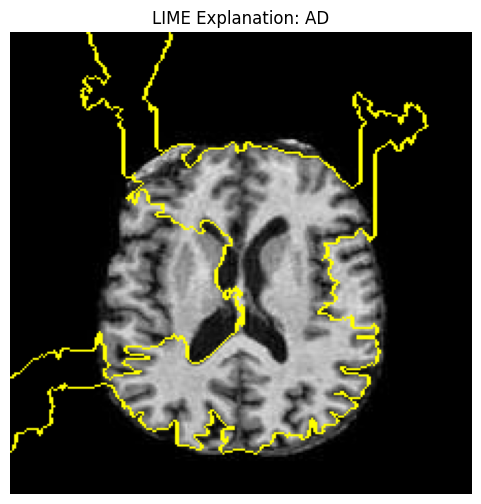

AttributeError: module 'matplotlib.pyplot' has no attribute 'save'

In [7]:
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# -----------------------------
# Configuration
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_PATH = "F://rgb_converted_dataset/test/AD/dim0_slice112I59174_brainMaskedByDL.jpg"  # <-- replace with your test image
MODEL_PATH = "tinyvit_ad_rgb.pth"  # <-- path to trained model
CLASS_NAMES = ['AD', 'CN', 'MCI']

# -----------------------------
# Image Transforms
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# -----------------------------
# Load Trained Model
# -----------------------------
model = timm.create_model('vit_tiny_patch16_224', pretrained=True)
model.head = torch.nn.Linear(model.head.in_features, len(CLASS_NAMES))
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device).eval()

# -----------------------------
# Prepare Image
# -----------------------------
original_img = Image.open(IMG_PATH).convert("RGB").resize((224, 224))
img_tensor = transform(original_img).unsqueeze(0).to(device)

# -----------------------------
# LIME Explanation
# -----------------------------
print("Running LIME...")

def predict_fn(images):
    # Normalize and convert to tensor batch: [N, 3, 224, 224]
    images = torch.tensor(images.transpose((0, 3, 1, 2)), dtype=torch.float32) / 255.0
    images = transforms.Normalize([0.5]*3, [0.5]*3)(images)
    images = images.to(device)
    with torch.no_grad():
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

img_np = np.array(original_img)
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    img_np,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=8,
    hide_rest=False
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"LIME Explanation: {CLASS_NAMES[explanation.top_labels[0]]}")
plt.axis('off')
plt.show()
plt.save()


Running SHAP...


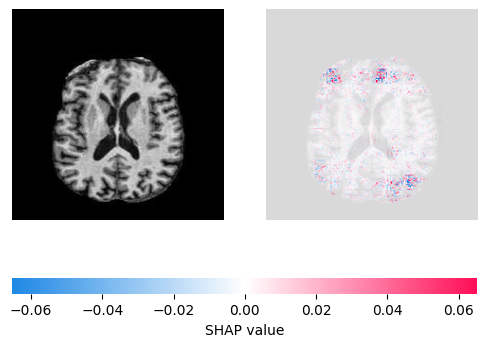

In [11]:

# -----------------------------
# SHAP Explanation
# -----------------------------
print("Running SHAP...")

# Background batch (5 random RGB training images)
background_dataset = ImageFolder("F://rgb_converted_dataset/train/", transform=transform)
background_loader = DataLoader(background_dataset, batch_size=5, shuffle=True)
background = next(iter(background_loader))[0].to(device)

# SHAP GradientExplainer
e = shap.GradientExplainer(model, background)
shap_values = e.shap_values(img_tensor)

# Convert input image to SHAP format
# Convert to shape: (1, H, W, C) and scale from [-1, 1] to [0, 1]
img_shap = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
img_shap = (img_shap * 0.5) + 0.5  # de-normalize
img_shap = np.clip(img_shap, 0, 1)  # ensure valid pixel range
img_shap = img_shap[np.newaxis, ...]  # add batch dimension

shap.image_plot([shap_values[0]], img_shap, show=True)


In [14]:
import os
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap

# -----------------------------
# Config
# -----------------------------
IMAGE_FOLDER = "F://rgb_converted_dataset/xai"
MODEL_PATH = "tinyvit_ad_rgb.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['AD', 'CN', 'MCI']
SAVE_DIR = "xai_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

# -----------------------------
# Transforms
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# -----------------------------
# Load Model
# -----------------------------
model = timm.create_model('vit_tiny_patch16_224', pretrained=False)
model.head = torch.nn.Linear(model.head.in_features, len(CLASS_NAMES))
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE).eval()

# -----------------------------
# LIME Predict Function
# -----------------------------
def predict_fn(images):
    images = torch.tensor(images.transpose((0, 3, 1, 2)), dtype=torch.float32) / 255.0
    images = transforms.Normalize([0.5]*3, [0.5]*3)(images)
    with torch.no_grad():
        outputs = model(images.to(DEVICE))
        probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

# -----------------------------
# SHAP Background (5 random images)
# -----------------------------
background = []
for fname in sorted(os.listdir(IMAGE_FOLDER))[:5]:
    img = Image.open(os.path.join(IMAGE_FOLDER, fname)).convert("RGB")
    img = transform(img)
    background.append(img)
background = torch.stack(background).to(DEVICE)
shap_explainer = shap.GradientExplainer(model, background)

# -----------------------------
# Iterate Over Images
# -----------------------------
for fname in sorted(os.listdir(IMAGE_FOLDER)):
    if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    print(f"Explaining: {fname}")
    img_path = os.path.join(IMAGE_FOLDER, fname)
    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
    img_np = np.array(img_pil)
    img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

    # -----------------------------------
    # LIME
    # -----------------------------------
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_np,
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=8,
        hide_rest=False
    )
    lime_fig = plt.figure()
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title(f"LIME: {CLASS_NAMES[explanation.top_labels[0]]}")
    plt.axis("off")
    lime_fig.savefig(os.path.join(SAVE_DIR, f"{fname}_lime.png"))
    plt.close()

   

Explaining: dim0_slice0 (397)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg


  0%|          | 0/1000 [00:00<?, ?it/s]

Explaining: dim0_slice0 (399)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg


  0%|          | 0/1000 [00:00<?, ?it/s]

Explaining: dim0_slice0 (402)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg


...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [16]:
    shap_values = shap_explainer.shap_values(img_tensor)
    img_shap = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img_shap = ((img_shap * 0.5) + 0.5).clip(0, 1)
    img_shap = img_shap[np.newaxis, ...]

    shap_fig = plt.figure()
    shap.image_plot([shap_values[0]], img_shap, show=False)
    shap_fig.savefig(os.path.join(SAVE_DIR, f"{fname}_shap.png"))
    plt.close()


<Figure size 640x480 with 0 Axes>

In [27]:
import os
import torch
import timm
import shap
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# -----------------------------
# Config
# -----------------------------
IMAGE_FOLDER = "F://rgb_converted_dataset/xai"
MODEL_PATH = "C:/Users/sushm/Documents/best_seresnet50.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['AD', 'CN', 'MCI']
SAVE_DIR = "seresnet/new_shap_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

# -----------------------------
# Transforms
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# -----------------------------
# Load Model
# -----------------------------
model = timm.create_model('seresnet50', pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, len(CLASS_NAMES))
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE).eval()

# -----------------------------
# Background Data for SHAP
# -----------------------------
background_images = []
for fname in sorted(os.listdir(IMAGE_FOLDER))[:5]:
    img = Image.open(os.path.join(IMAGE_FOLDER, fname)).convert("RGB")
    img = transform(img)
    background_images.append(img)
background = torch.stack(background_images).to(DEVICE)

# Create SHAP GradientExplainer
explainer = shap.GradientExplainer(model, background)

# -----------------------------
# Iterate over all images
# -----------------------------
for fname in sorted(os.listdir(IMAGE_FOLDER)):
    if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    print(f"Explaining with SHAP: {fname}")
    img_path = os.path.join(IMAGE_FOLDER, fname)
    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
    img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

    # Get SHAP values
    shap_values = explainer.shap_values(img_tensor)

    # De-normalize for visualization
    img_np = img_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img_np = ((img_np * 0.5) + 0.5).clip(0, 1)
    img_np = img_np[np.newaxis, ...]  # shape (1, H, W, C)

    # Plot and save SHAP explanation
    plt.figure()
    shap.image_plot([shap_values[0]], img_np, show=False)
    plt.savefig(os.path.join(SAVE_DIR, f"{fname}_shap.png"))
    plt.close()


Explaining with SHAP: dim0_slice0 (397)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg
Explaining with SHAP: dim0_slice0 (399)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg
Explaining with SHAP: dim0_slice0 (402)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg
Explaining with SHAP: dim0_slice103I80152_brainMaskedByDL.jpg
Explaining with SHAP: dim0_slice104I103276_brainMaskedByDL.jpg
Explaining with SHAP: dim0_slice104I59677_brainMaskedByDL.jpg
Explaining with SHAP: dim0_slice114I52138_brainMaskedByDL.jpg
Explaining with SHAP: dim0_slice96I120256_brainMaskedByDL.jpg
Explaining with SHAP: dim0_slice97I88270_brainMaskedByDL.jpg
Explaining with SHAP: dim0_slice98I59174_brainMaskedByDL.jpg


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [18]:
pip install shap timm torch torchvision matplotlib


Note: you may need to restart the kernel to use updated packages.


In [22]:
import shap
import os
import numpy as np
import torch
import timm
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from matplotlib.colors import Normalize

# --------------------------
2# --------------------------
IMAGE_DIR = "F://rgb_converted_dataset/xai"
SAVE_DIR = "new_shap_outputs"
MODEL_PATH = "tinyvit_ad_rgb.pth"
os.makedirs(SAVE_DIR, exist_ok=True)

CLASS_NAMES = ['AD', 'CN', 'MCI']
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------
# Load Model
# --------------------------
model = timm.create_model("vit_tiny_patch16_224", pretrained=False, num_classes=len(CLASS_NAMES))
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# --------------------------
# Preprocessing
# --------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# --------------------------
# SHAP wrapper
# --------------------------
def model_predict(imgs):
    with torch.no_grad():
        imgs = torch.from_numpy(imgs).permute(0, 3, 1, 2).float().to(DEVICE)
        imgs = (imgs - 0.5) / 0.5  # normalize
        outputs = model(imgs)
        probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

# --------------------------
# SHAP Visualizer
# --------------------------
def plot_shap_overlay(shap_vals, image, save_path, alpha=0.6, cmap='jet'):
    heatmap = shap_vals.sum(-1)
    norm = Normalize(vmin=-np.max(np.abs(heatmap)), vmax=np.max(np.abs(heatmap)))

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.imshow(heatmap, cmap=cmap, norm=norm, alpha=alpha)
    plt.colorbar()
    plt.title("SHAP Overlay")
    plt.axis('off')
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close()

# --------------------------
# Load one background image
# --------------------------
bg_img_path = sorted(os.listdir(IMAGE_DIR))[0]
bg_img = Image.open(os.path.join(IMAGE_DIR, bg_img_path)).convert("RGB").resize((224, 224))
bg_np = np.array(bg_img) / 255.0
background = np.array([bg_np])

# --------------------------
# SHAP Explainer (KernelExplainer)
# --------------------------
explainer = shap.KernelExplainer(model_predict, background)

# --------------------------
# Batch Process Images
# --------------------------
for fname in sorted(os.listdir(IMAGE_DIR)):
    if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    print(f"Processing: {fname}")
    img_path = os.path.join(IMAGE_DIR, fname)
    img = Image.open(img_path).convert("RGB").resize((224, 224))
    img_np = np.array(img) / 255.0

    shap_vals = explainer.shap_values(np.array([img_np]), nsamples=100)

    # Use the class with highest probability
    class_idx = np.argmax(model_predict(np.array([img_np])))

    save_path = os.path.join(SAVE_DIR, f"{os.path.splitext(fname)[0]}_shap_{CLASS_NAMES[class_idx]}.png")
    plot_shap_overlay(shap_vals[class_idx][0], img_np, save_path)

print("✅ SHAP explanations saved in:", SAVE_DIR)


Processing: dim0_slice0 (397)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg


DimensionError: Instance must have 1 or 2 dimensions!

In [25]:
import os
import torch
import timm
import shap
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from matplotlib.colors import Normalize

# CONFIG
IMAGE_DIR = "F://rgb_converted_dataset/xai"
SAVE_DIR = "new_shap_outputs"
MODEL_PATH = "tinyvit_ad_rgb.pth"
os.makedirs(SAVE_DIR, exist_ok=True)

CLASS_NAMES = ['AD', 'CN', 'MCI']
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load model
model = timm.create_model("vit_tiny_patch16_224", pretrained=False, num_classes=len(CLASS_NAMES))
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# Transform for images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Prediction wrapper for SHAP (expects tensor input)
def model_predict_torch(x):
    x = x.to(DEVICE)
    x = (x - 0.5) / 0.5  # normalize to approx [-1,1]
    with torch.no_grad():
        outputs = model(x)
        probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

# SHAP overlay plot function
def plot_shap_overlay(shap_vals, image, save_path, alpha=0.6, cmap='jet'):
    heatmap = shap_vals.sum(-1)  # sum over channels
    norm = Normalize(vmin=-np.max(np.abs(heatmap)), vmax=np.max(np.abs(heatmap)))

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.imshow(heatmap, cmap=cmap, norm=norm, alpha=alpha)
    plt.colorbar()
    plt.title("SHAP Overlay")
    plt.axis('off')
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close()

# Load some background samples for SHAP (e.g. 10 random images)
background_imgs = []
files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(('.png','.jpg','.jpeg'))])
for fname in files[:10]:
    img = Image.open(os.path.join(IMAGE_DIR, fname)).convert("RGB")
    img_t = transform(img)
    background_imgs.append(img_t)

background = torch.stack(background_imgs).to(DEVICE)

# Create GradientExplainer with background dataset
explainer = shap.GradientExplainer(model, background)

# Process images one by one
for fname in files:
    print(f"Processing {fname} ...")
    img_path = os.path.join(IMAGE_DIR, fname)
    img = Image.open(img_path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(DEVICE)  # shape (1,3,224,224)
    img_np = np.array(img.resize((224, 224))) / 255.0

    # Get predicted class
    probs = model_predict_torch(img_t)
    class_idx = np.argmax(probs)

    # Calculate SHAP values
    shap_values = explainer.shap_values(img_t)
    print("Output shape:", model(img_t).shape)
    # SHAP values shape: (num_classes, batch_size=1, channels, height, width)
    shap_img = shap_values[class_idx][0].permute(1, 2, 0).cpu().numpy()
    

    # Plot and save overlay
    save_path = os.path.join(SAVE_DIR, f"{os.path.splitext(fname)[0]}_shap_{CLASS_NAMES[class_idx]}.png")
    plot_shap_overlay(shap_img, img_np, save_path)

print("✅ SHAP explanations saved in:", SAVE_DIR)


Processing dim0_slice0 (397)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg ...
Output shape: torch.Size([1, 3])


IndexError: index 1 is out of bounds for axis 0 with size 1

In [29]:
import os
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap

# -----------------------------
# Config
# -----------------------------
IMAGE_FOLDER = "F://rgb_converted_dataset/xai"
MODEL_PATH = "C:/Users/sushm/Documents/best_seresnet50.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['AD', 'CN', 'MCI']
SAVE_DIR = "xai_outputs/seresnet"
os.makedirs(SAVE_DIR, exist_ok=True)

# -----------------------------
# Transforms
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# -----------------------------
# Load Model
# -----------------------------
model = timm.create_model('seresnet50', pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, len(CLASS_NAMES))
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE).eval()

# -----------------------------
# LIME Predict Function
# -----------------------------
def predict_fn(images):
    images = torch.tensor(images.transpose((0, 3, 1, 2)), dtype=torch.float32) / 255.0
    images = transforms.Normalize([0.5]*3, [0.5]*3)(images)
    with torch.no_grad():
        outputs = model(images.to(DEVICE))
        probs = torch.nn.functional.softmax(outputs, dim=1)
    return probs.cpu().numpy()

# -----------------------------
# SHAP Background (5 random images)
# -----------------------------
background = []
for fname in sorted(os.listdir(IMAGE_FOLDER))[:5]:
    img = Image.open(os.path.join(IMAGE_FOLDER, fname)).convert("RGB")
    img = transform(img)
    background.append(img)
background = torch.stack(background).to(DEVICE)
shap_explainer = shap.GradientExplainer(model, background)

# -----------------------------
# Iterate Over Images
# -----------------------------
for fname in sorted(os.listdir(IMAGE_FOLDER)):
    if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    print(f"Explaining: {fname}")
    img_path = os.path.join(IMAGE_FOLDER, fname)
    img_pil = Image.open(img_path).convert("RGB").resize((224, 224))
    img_np = np.array(img_pil)
    img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

    # -----------------------------------
    # LIME
    # -----------------------------------
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_np,
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=8,
        hide_rest=False
    )
    lime_fig = plt.figure()
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title(f"LIME: {CLASS_NAMES[explanation.top_labels[0]]}")
    plt.axis("off")
    lime_fig.savefig(os.path.join(SAVE_DIR, f"{fname}_lime.png"))
    plt.close()

   

Explaining: dim0_slice0 (397)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg


  0%|          | 0/1000 [00:00<?, ?it/s]

Explaining: dim0_slice0 (399)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg


  0%|          | 0/1000 [00:00<?, ?it/s]

Explaining: dim0_slice0 (402)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg


...

  0%|          | 0/1000 [00:00<?, ?it/s]

Explaining: dim0_slice97I88270_brainMaskedByDL.jpg


  0%|          | 0/1000 [00:00<?, ?it/s]

Explaining: dim0_slice98I59174_brainMaskedByDL.jpg


  0%|          | 0/1000 [00:00<?, ?it/s]

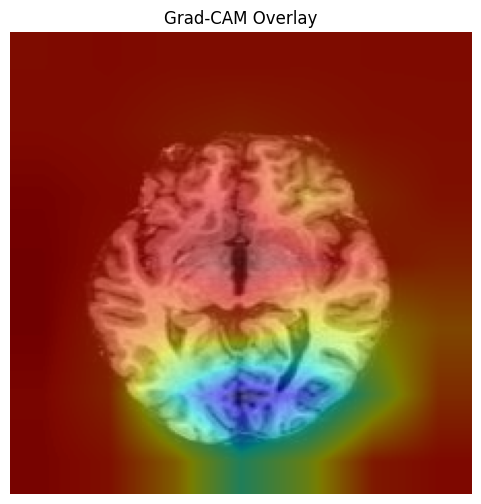

In [4]:

import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from captum.attr import LayerGradCam, LayerAttribution

# ----------------------------
# 1. Load the Trained Model
# ----------------------------
model = timm.create_model('ecaresnet50t.a2_in1k', pretrained=False, num_classes=3)
model.load_state_dict(torch.load('C://Users//sushm//Documents//best_ecaresnet_model.pth', map_location='cpu'))
model.eval()

# ----------------------------
# 2. Load and Preprocess Image
# ----------------------------
img_path = 'F://rgb_converted_dataset/train/CN/dim0_slice0 (397)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg'
image = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

input_tensor = transform(image).unsqueeze(0)  # Shape: [1, 3, 224, 224]

# ----------------------------
# 3. Set Up Grad-CAM
# ----------------------------
target_layer = model.layer4[-1] # Last conv layer for ECAResNet
gradcam = LayerGradCam(model, target_layer)
target_class = 0  # Change if needed

# Compute Grad-CAM Attribution
attributions = gradcam.attribute(input_tensor, target=target_class)
upsampled_attr = LayerAttribution.interpolate(attributions, (224, 224), interpolate_mode='bilinear')

# ----------------------------
# 4. Visualize Grad-CAM
# ----------------------------
# Unnormalize image for display
input_np = input_tensor.squeeze().permute(1, 2, 0).detach().numpy()
input_np = (input_np * 0.5) + 0.5
input_np = np.clip(input_np, 0, 1)

# Grad-CAM heatmap
attr_np = upsampled_attr.squeeze().cpu().detach().numpy()
attr_np = (attr_np - np.min(attr_np)) / (np.max(attr_np) - np.min(attr_np))  # Normalize for colormap

# Plot overlay
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(input_np)
ax.imshow(attr_np, cmap='jet', alpha=0.5)
ax.set_title('Grad-CAM Overlay')
ax.axis('off')
plt.show()


C:\Users\sushm\anaconda3\envs\pitorch\lib\site-packages\captum\log\dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


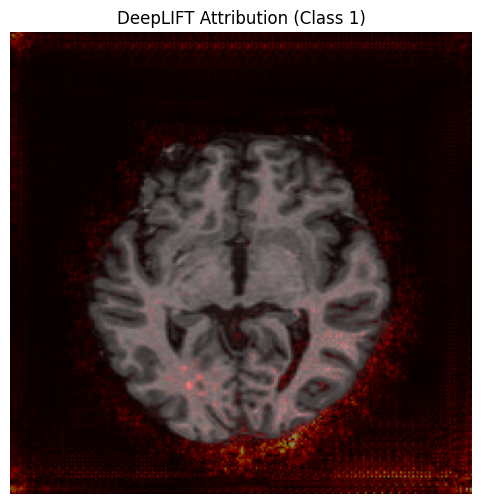

In [5]:
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from captum.attr import DeepLift

# ----------------------------
# 1. Load the Trained Model
# ----------------------------
model = timm.create_model('ecaresnet50t.a2_in1k', pretrained=False, num_classes=3)
model.load_state_dict(torch.load('C://Users//sushm//Documents//best_ecaresnet_model.pth', map_location='cpu'))
model.eval()

# ----------------------------
# 2. Load and Preprocess Image
# ----------------------------
img_path = 'F://rgb_converted_dataset/train/CN/dim0_slice0 (397)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg'
image = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

input_tensor = transform(image).unsqueeze(0)  # Shape: [1, 3, 224, 224]
input_tensor.requires_grad = True

# ----------------------------
# 3. Setup DeepLIFT
# ----------------------------
deeplift = DeepLift(model)

# Choose target class (optional: can be predicted class)
output = model(input_tensor)
pred_class = torch.argmax(output, dim=1).item()

# Use zero tensor as baseline (same shape as input)
baseline = torch.zeros_like(input_tensor)

# Compute attributions
attributions = deeplift.attribute(input_tensor, baseline, target=pred_class)
attr = attributions.squeeze().detach().cpu().numpy()
attr = np.transpose(attr, (1, 2, 0))  # C,H,W -> H,W,C

# Normalize attributions for visualization
attr_norm = np.abs(attr).mean(axis=2)
attr_norm = (attr_norm - attr_norm.min()) / (attr_norm.max() - attr_norm.min() + 1e-8)

# ----------------------------
# 4. Visualization
# ----------------------------
# Unnormalize input image for display
input_np = input_tensor.squeeze().permute(1, 2, 0).detach().numpy()
input_np = (input_np * 0.5) + 0.5
input_np = np.clip(input_np, 0, 1)

# Plot overlay
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(input_np)
ax.imshow(attr_norm, cmap='hot', alpha=0.5)
ax.set_title(f'DeepLIFT Attribution (Class {pred_class})')
ax.axis('off')
plt.show()


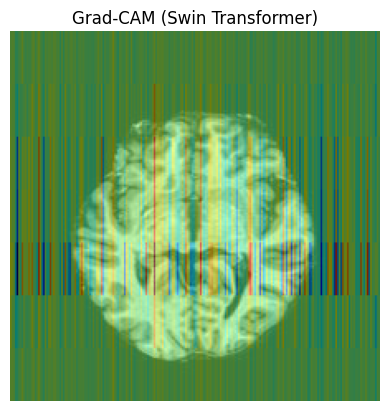

  0%|          | 0/1000 [00:00<?, ?it/s]

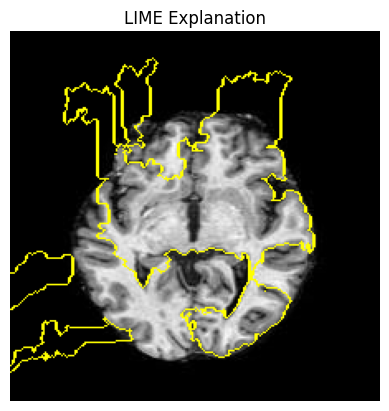

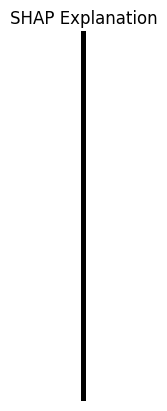

In [6]:
# ===============================
# 1. Imports
# ===============================
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap

from captum.attr import LayerGradCam, LayerAttribution
import warnings
warnings.filterwarnings("ignore")

# ===============================
# 2. Load Pretrained Swin Transformer
# ===============================
model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=3)
model.load_state_dict(torch.load('C://Users//sushm//Documents//best_swin_model.pth', map_location='cpu'))
model.eval()

# Modify if your model is fine-tuned:
# model.head = torch.nn.Linear(model.head.in_features, 3)

# ===============================
# 3. Image Preprocessing
# ===============================
img_path = "F://rgb_converted_dataset/train/CN/dim0_slice0 (397)I118675_brainMaskedByDLI118675_brainMaskedByDL.jpg"  # 🔁 Replace this
image = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

input_tensor = transform(image).unsqueeze(0)
input_tensor.requires_grad = True

# Unnormalized for visualization
unnorm = transforms.Compose([
    transforms.Resize((224, 224))
])
input_img_np = np.array(unnorm(image)).astype(np.float32) / 255.0

# ===============================
# 4. Grad-CAM on Transformer
# ===============================
# Grad-CAM on last block before classification (last norm layer in Swin)
target_layer = model.norm

gradcam = LayerGradCam(model, target_layer)
output = model(input_tensor)
target_class = torch.argmax(output, dim=1).item()

attributions = gradcam.attribute(input_tensor, target=target_class)
cam = LayerAttribution.interpolate(attributions, (224, 224)).squeeze().detach().cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min())

# 🔥 Visualize Grad-CAM
plt.imshow(input_img_np)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Grad-CAM (Swin Transformer)")
plt.axis('off')
plt.show()

# ===============================
# 5. LIME
# ===============================
explainer = lime_image.LimeImageExplainer()

def predict_fn(images):
    batch = torch.stack([
        transform(Image.fromarray(img)).float() for img in images
    ])
    outputs = model(batch)
    return outputs.detach().numpy()

explanation = explainer.explain_instance(np.array(image), 
                                         predict_fn,
                                         top_labels=1, 
                                         hide_color=0,
                                         num_samples=1000)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis('off')
plt.show()

# ===============================
# 6. SHAP on Swin Transformer
# ===============================
# Create background
background = input_tensor.repeat(5, 1, 1, 1)

# Use shap DeepExplainer
e = shap.DeepExplainer(model, background)
shap_values = e.shap_values(input_tensor)

# Convert for plotting
shap_numpy = np.transpose(input_tensor.squeeze().detach().numpy(), (1,2,0))
shap_values_np = shap_values[0][0].transpose(1,2,0)

# Mean of channels
shap_map = np.abs(shap_values_np).mean(-1)

# Normalize
shap_map = (shap_map - shap_map.min()) / (shap_map.max() - shap_map.min())

# Plot
plt.imshow(input_img_np)
plt.imshow(shap_map, cmap='coolwarm', alpha=0.5)
plt.title("SHAP Explanation")
plt.axis('off')
plt.show()
